# Leaf temperature
> Daily leaf temperature, its rate of change and leaf minus air temperature, per node

This module turns the measurements of `clean` into one leaf temperature series per node and day. Each thermal image also shows background, so a mask keeps only the leaf pixels: the pixels that vary most over time, since a leaf warms and cools more than its surroundings. From the masked pixels, each image gives one leaf temperature. Its rate of change, from a Savitzky-Golay filter, and its difference to air temperature are the signatures to compare across days and nodes.

In [ ]:
#| default_exp leaf

In [ ]:
#| export
import itertools
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from speaking_plants.clean import frames
from astral import LocationInfo
from astral.sun import sun

In [ ]:
from fastcore.utils import *
from fastcore.test import *
from speaking_plants.clean import *

## Data

The input is one row per measurement, from `measurements`, with the Ruuvi readings of `SP_01` shared with every node by `share_ruuvi`. The examples use batch 1, from `data/b01/`:

In [ ]:
#| eval: false
data = Path('../data/b01')
mdf = share_ruuvi(measurements(clean(read_logs(sorted(data.glob('dados_*.csv'))))))

## Full days

A day of measurements every 5 minutes has 288 of them. Only days close to that show the whole daily cycle, so the analysis keeps node-days with at least `min_n` measurements. Days run from midnight to midnight, local time.

In [ ]:
#| export
def full_days(
    df:pd.DataFrame, # Output of `measurements`
    min_n:int=280, # Fewest measurements for a full day
)->pd.DataFrame: # One row per full day, with `node_id` and `day`
    "Node-days with at least `min_n` measurements"
    n = df.groupby(['node_id', df.time.dt.normalize().rename('day')]).size()
    return n[n >= min_n].reset_index()[['node_id', 'day']]

In [ ]:
#| eval: false
days = full_days(mdf)
days.assign(v='✓').pivot(index='day', columns='node_id', values='v').fillna('')

node_id,SP_01,SP_02,SP_03,SP_04
day,,,,
2026-09-25,✓,,,
2026-09-26,,,,✓
2026-09-29,✓,✓,✓,✓
2026-10-01,✓,,✓,✓
2026-10-02,✓,✓,✓,✓
2026-10-03,,✓,,✓
2026-10-04,,✓,,✓


## Leaf masks

The standard deviation of each pixel over time maps where the temperature moves. `top_mask` keeps the pixels above the `q` quantile of that map, so `q=0.9` keeps the 10% that vary most. Pixels that `clean` set to missing are ignored.

In [ ]:
#| export
def std_map(
    df:pd.DataFrame, # Rows of `measurements` output
)->np.ndarray: # Shape `(24, 32)`, standard deviation of each pixel over the rows
    "Standard deviation of each pixel over time"
    return np.nanstd(frames(df), axis=0)

def top_mask(
    sd:np.ndarray, # Output of `std_map`
    q:float=0.9, # Quantile above which a pixel counts as leaf
)->np.ndarray: # Boolean, same shape as `sd`
    "Pixels whose standard deviation is above the `q` quantile"
    return sd > np.nanquantile(sd, q)

A mask can come from each day or from a node's whole batch. A daily mask follows the leaf if the plant or the camera moves, but a day with little temperature variation may pick up background. A batch mask is the same for every day of a node, which keeps the days comparable. A batch mask is only valid while the camera scene stays the same, as the section on scene changes explains. `no_masks` keeps every pixel. Its profile is the reference, since a mask is only useful if it changes the result compared with all pixels. All three functions return a mask per node-day, and the rest of the analysis takes any of them:

In [ ]:
#| export
def _day(df, node, day): return df[(df.node_id == node) & (df.time.dt.normalize() == day)]

def daily_masks(
    df:pd.DataFrame, # Output of `measurements`
    days:pd.DataFrame, # Output of `full_days`
    q:float=0.9, # Quantile above which a pixel counts as leaf
)->dict: # Mask per `(node_id, day)`, from that day's images
    "One leaf mask per node-day, from that day"
    return {(r.node_id, r.day): top_mask(std_map(_day(df, r.node_id, r.day)), q) for r in days.itertuples()}

def batch_masks(
    df:pd.DataFrame, # Output of `measurements`
    days:pd.DataFrame, # Output of `full_days`
    q:float=0.9, # Quantile above which a pixel counts as leaf
)->dict: # Mask per `(node_id, day)`, from all of the node's images
    "One leaf mask per node, from all its images, repeated for each of its days"
    ms = {n: top_mask(std_map(g), q) for n, g in df.groupby('node_id')}
    return {(r.node_id, r.day): ms[r.node_id] for r in days.itertuples()}

def no_masks(
    days:pd.DataFrame, # Output of `full_days`
)->dict: # All-pixel mask per `(node_id, day)`
    "Masks that keep every pixel, for the unmasked profile"
    return {(r.node_id, r.day): np.ones((24, 32), bool) for r in days.itertuples()}

In [ ]:
#| eval: false
dm, bm = daily_masks(mdf, days), batch_masks(mdf, days)

## Leaf temperature series

`leaf_series` reduces each image to the median of its masked pixels, the leaf temperature `t_leaf`. It puts each node-day on a regular grid with a step of `step`, so a missing measurement is a missing value rather than a longer interval. `slope` then smooths and differentiates the series with a Savitzky-Golay filter, in °C per minute. The filter needs equally spaced values, so it runs on each stretch without missing values, and stretches shorter than `window` get no slope. With a 5-minute step, the default window of 9 spans 45 minutes. `smooth` uses the same filter without differentiating, for the `t_smooth` and `dt_smooth` columns. Its default window of 13 spans 1 hour. That removes the fluctuations of a few minutes that appear in daytime only and on all nodes at once, most likely changes in sunlight.

In [ ]:
#| export
def regular(
    s:pd.Series, # Values indexed by time
    step:str='5min', # Grid step
)->pd.Series: # Values on a grid from the first time, missing where no value is within half a step
    "Put a time series on a regular grid"
    grid = pd.date_range(s.index[0], s.index[-1], freq=step, name='time')
    return s.reindex(grid, method='nearest', tolerance=pd.Timedelta(step) / 2)

def _savgol(s, window, polyorder, deriv):
    "Savitzky-Golay filter on each stretch of `s` without missing values, per minute"
    step = s.index.freq.nanos / 60e9
    out, ok = pd.Series(np.nan, index=s.index), s.notna()
    for _, v in s[ok].groupby((ok != ok.shift()).cumsum()[ok]):
        if len(v) >= window: out[v.index] = savgol_filter(v.to_numpy(), window, polyorder, deriv=deriv, delta=step)
    return out

def smooth(
    s:pd.Series, # Output of `regular`
    window:int=13, # Points in the Savitzky-Golay window
    polyorder:int=3, # Order of the fitted polynomial
)->pd.Series: # Smoothed values, missing on stretches shorter than `window`
    "Smoothed regular series"
    return _savgol(s, window, polyorder, 0)

def slope(
    s:pd.Series, # Output of `regular`
    window:int=9, # Points in the Savitzky-Golay window
    polyorder:int=3, # Order of the fitted polynomial
)->pd.Series: # Rate of change per minute, missing on stretches shorter than `window`
    "Smoothed first derivative of a regular series"
    return _savgol(s, window, polyorder, 1)

In [ ]:
t = pd.date_range('2026-10-01', periods=30, freq='5min')
s = regular(pd.Series(2. * np.arange(30), index=t + pd.Timedelta('1s')))
test_close(slope(s).to_numpy(), np.full(30, 0.4))
test_close(smooth(s).to_numpy(), s.to_numpy())

Transpiration is driven by the vapour pressure deficit (VPD): the gap between the vapour pressure of saturated air at the air temperature and the actual vapour pressure. A plant that transpires well cools more below the air as VPD rises. `vpd` computes it in kPa from the Ruuvi temperature and relative humidity, with the Tetens formula for the saturation vapour pressure, and `leaf_series` adds it as the `vpd` column.

In [ ]:
#| export
def vpd(
    t, # Air temperature (°C)
    rh, # Relative humidity (%)
): # Vapour pressure deficit (kPa)
    "Vapour pressure deficit, with the Tetens formula for the saturation vapour pressure"
    return 0.6108 * np.exp(17.27 * t / (t + 237.3)) * (1 - rh / 100)

At 25 °C, saturated air holds 3.17 kPa of water vapour. Air at 60% relative humidity then has a deficit of 1.27 kPa:


In [ ]:
test_close(vpd(25, 60), 1.267, eps=1e-3)
test_eq(vpd(20, 100), 0)

In [ ]:
#| export
def leaf_series(
    df:pd.DataFrame, # Output of `share_ruuvi`
    masks:dict, # Output of `daily_masks`, `batch_masks` or `no_masks`
    step:str='5min', # Grid step
    window:int=9, # Points in the Savitzky-Golay window of `slope`
    polyorder:int=3, # Order of the fitted polynomial
    smooth_window:int=13, # Points in the smoothing window of `t_smooth` and `dt_smooth`
)->pd.DataFrame: # One row per grid time and node-day
    "Leaf temperature, air temperature and VPD, leaf minus air, raw and smoothed, and the leaf slope, per node-day"
    res = []
    for (node, day), mask in masks.items():
        g = _day(df, node, day)
        t = g.time.to_numpy()
        leaf = regular(pd.Series(np.nanmedian(frames(g)[:, mask], axis=1), index=t), step)
        air = regular(pd.Series(g.ruuvi_temp.to_numpy(), index=t), step)
        rh = regular(pd.Series(g.ruuvi_humidity.to_numpy(), index=t), step)
        res.append(pd.DataFrame(dict(node_id=node, day=day, t_leaf=leaf, t_smooth=smooth(leaf, smooth_window, polyorder),
                                     t_air=air, vpd=vpd(air, rh), dt_leaf_air=leaf - air, dt_smooth=smooth(leaf - air, smooth_window, polyorder),
                                     slope=slope(leaf, window, polyorder))).reset_index())
    out = pd.concat(res, ignore_index=True)
    out.insert(3, 'hour', (out.time - out.day).dt.total_seconds() / 3600)
    return out

In [ ]:
#| eval: false
ls = leaf_series(mdf, no_masks(days))
ls.head()

,time,node_id,day,hour,t_leaf,t_smooth,t_air,vpd,dt_leaf_air,dt_smooth,slope
0,2026-09-25 00:00:00,SP_01,2026-09-25,0.000000,22.045,22.023571,NaN,NaN,NaN,NaN,-0.010531
1,2026-09-25 00:05:00,SP_01,2026-09-25,0.083333,21.955,21.999945,19.94,1.129395,2.015,NaN,-0.006806
2,2026-09-25 00:10:00,SP_01,2026-09-25,0.166667,21.980,21.973666,19.93,1.127066,2.050,NaN,-0.004375
3,2026-09-25 00:15:00,SP_01,2026-09-25,0.250000,21.960,21.945749,19.91,1.126601,2.050,NaN,-0.003236
4,2026-09-25 00:20:00,SP_01,2026-09-25,0.333333,21.935,21.917208,NaN,NaN,NaN,NaN,-0.003391


`hour` is the time of day, which lines days up on one axis. `plot_panels` draws one panel per value of `panel` and one line per value of `line`:

In [ ]:
#| export
def plot_panels(
    df:pd.DataFrame, # Output of `leaf_series`
    col:str, # Column to plot against `hour`
    panel:str='node_id', # Column with one panel per value
    line:str='day', # Column with one line per value
    ylabel:str=None, # Label of the y axis, `col` by default
    title:str='', # Prefix of each panel title
):
    "Plot `col` against time of day, one panel per `panel` value and one line per `line` value"
    keys = sorted(df[panel].unique())
    fig, axs = plt.subplots(1, len(keys), figsize=(4.5 * len(keys), 3.2), sharey=True, squeeze=False)
    for ax, k in zip(axs[0], keys):
        for l, g in df[df[panel] == k].groupby(line):
            ax.plot(g.hour, g[col], lw=1, label=f'{l:%d %b}' if line == 'day' else l)
        ax.set_title(f'{title}{k:%d %b}' if panel == 'day' else f'{title}{k}', fontsize=10)
        ax.set_xticks(range(0, 25, 6)); ax.set_xlabel('hour'); ax.grid(alpha=0.3)
        ax.legend(fontsize=7)
    axs[0, 0].set_ylabel(ylabel or col)
    plt.tight_layout()

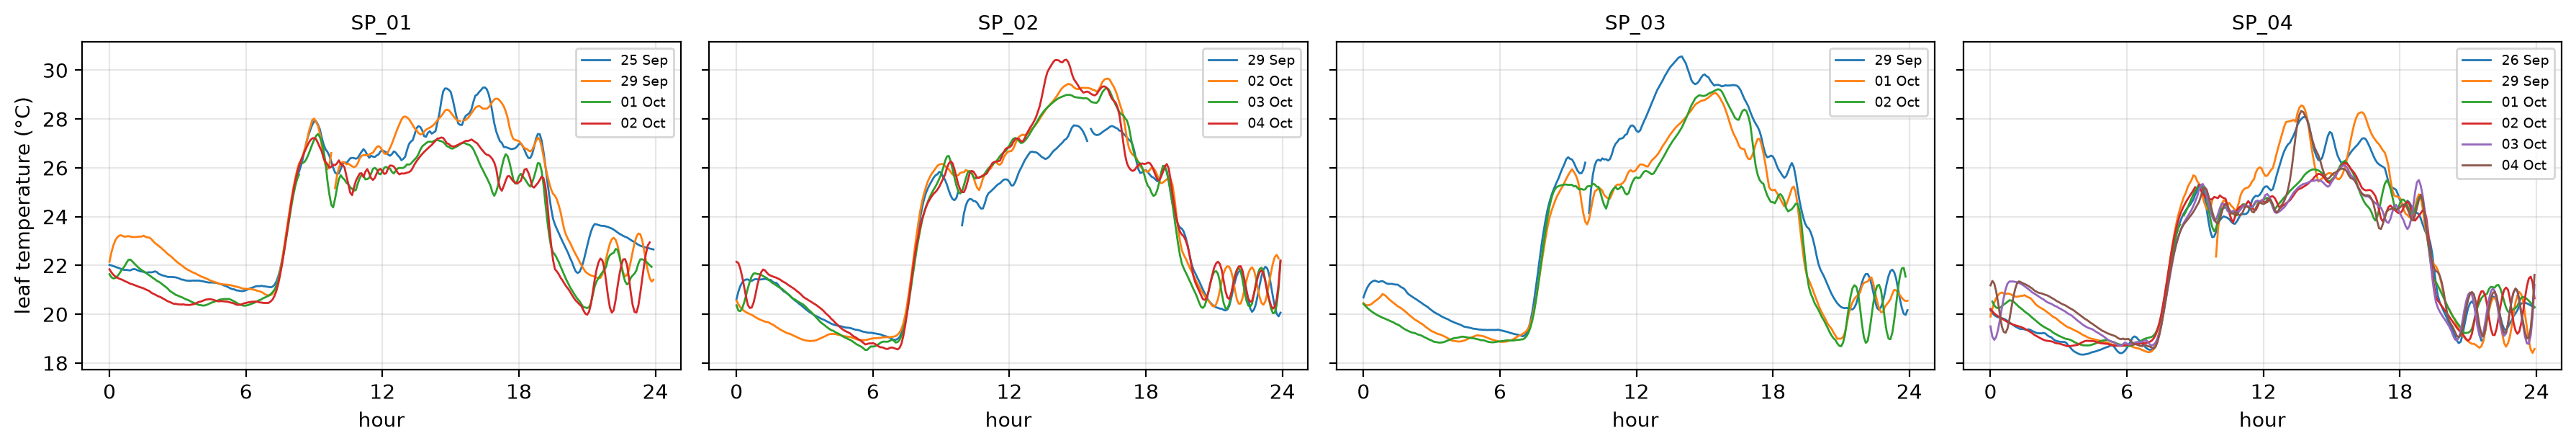

In [ ]:
#| eval: false
plot_panels(ls, 't_smooth', ylabel='leaf temperature (°C)')

## Daylight

Day and night follow sunrise and sunset, which shift by a few minutes each day. `sun_times` gets them from `astral` for a site. The default site is Seibersdorf, Austria, where the preliminary experiment ran. The times are Austrian local time, like `time` in the logs.

In [ ]:
#| export
site = LocationInfo('Seibersdorf', 'Austria', 'Europe/Vienna', 47.976, 16.508)

def sun_times(
    times, # Times or days, local time
    loc:LocationInfo=site, # Site of the greenhouse
)->pd.DataFrame: # One row per day, with dawn, sunrise, noon, sunset and dusk in local time
    "Sun events for each day in `times`"
    days = pd.DatetimeIndex(times).normalize().unique()
    evs = ('dawn', 'sunrise', 'noon', 'sunset', 'dusk')
    ss = [sun(loc.observer, date=d.date(), tzinfo=loc.timezone) for d in days]
    return pd.DataFrame({k: pd.to_datetime([s[k].replace(tzinfo=None) for s in ss]) for k in evs}, index=days.rename('day'))

def is_day(
    times, # Local times
    loc:LocationInfo=site, # Site of the greenhouse
)->np.ndarray: # True from sunrise to sunset
    "Whether each time is in daylight"
    t = pd.DatetimeIndex(times)
    st = sun_times(t, loc).reindex(t.normalize())
    return (t >= st.sunrise.to_numpy()) & (t < st.sunset.to_numpy())

In [ ]:
st = sun_times(pd.date_range('2026-09-23', '2026-10-05'))
test_eq(f"{st.sunrise.iloc[0]:%H:%M}-{st.sunset.iloc[0]:%H:%M}", '06:42-18:49')
test_eq(is_day(pd.to_datetime(['2026-09-30 03:00', '2026-09-30 06:30', '2026-09-30 07:00', '2026-09-30 18:30', '2026-09-30 18:40'])), [False, False, True, True, False])
st.apply(lambda s: s.dt.strftime('%H:%M'))

,dawn,sunrise,noon,sunset,dusk
day,,,,,
2026-09-23,06:10,06:42,12:46,18:49,19:21
2026-09-24,06:11,06:43,12:46,18:47,19:19
2026-09-25,06:13,06:44,12:45,18:45,19:17
2026-09-26,06:14,06:46,12:45,18:43,19:15
2026-09-27,06:16,06:47,12:45,18:41,19:12
2026-09-28,06:17,06:48,12:44,18:39,19:10
2026-09-29,06:18,06:50,12:44,18:37,19:08
2026-09-30,06:20,06:51,12:44,18:35,19:06
2026-10-01,06:21,06:53,12:43,18:33,19:04


## Scene changes

A camera that is moved, or a plant that is moved or replaced, changes what each pixel sees. Masks, biases and fitted lines are only valid within a stretch of days with the same scene. `scene_similarity` compares the daily standard deviation maps of each node. Two days with the same scene correlate highly. A low correlation between neighbouring days points to a change between them. Days with fewer than `min_n` measurements are left out, because a partial day covers only part of the daily cycle and its map is less reliable.

In [ ]:
#| export
def scene_similarity(
    df:pd.DataFrame, # Output of `measurements`
    min_n:int=144, # Fewest measurements for a day to be compared
)->dict: # Correlation matrix of daily standard deviation maps, per node
    "Correlation between the daily standard deviation maps of each node"
    res = {}
    for node, g in df.groupby('node_id'):
        maps = {d: std_map(gd).ravel() for d, gd in g.groupby(g.time.dt.normalize()) if len(gd) >= min_n}
        sim = pd.DataFrame(maps).corr()
        sim.index.name = sim.columns.name = 'day'
        res[node] = sim
    return res

def plot_scene_similarity(
    sim:dict, # Output of `scene_similarity`
):
    "One heatmap per node of the correlation between its days"
    fig, axs = plt.subplots(1, len(sim), figsize=(4.5 * len(sim), 4.2), squeeze=False)
    for ax, (node, m) in zip(axs[0], sim.items()):
        ax.imshow(m, vmin=0, vmax=1, cmap='viridis')
        labs = [f'{d:%d %b}' for d in m.index]
        ax.set_xticks(range(len(m)), labs, rotation=90, fontsize=7); ax.set_yticks(range(len(m)), labs, fontsize=7)
        for i, j in itertools.product(range(len(m)), repeat=2):
            ax.text(j, i, f'{m.iat[i, j]:.1f}', ha='center', va='center', fontsize=6, c='w' if m.iat[i, j] < 0.6 else 'k')
        ax.set_title(node, fontsize=10)
    plt.tight_layout()

In batch 1, all four nodes change on 30 September. `SP_01` also changes across the outage from 25 to 28 September. `SP_03` has no stable stretch before 30 September, and the 23 September map of `SP_02` matches none of its other days:

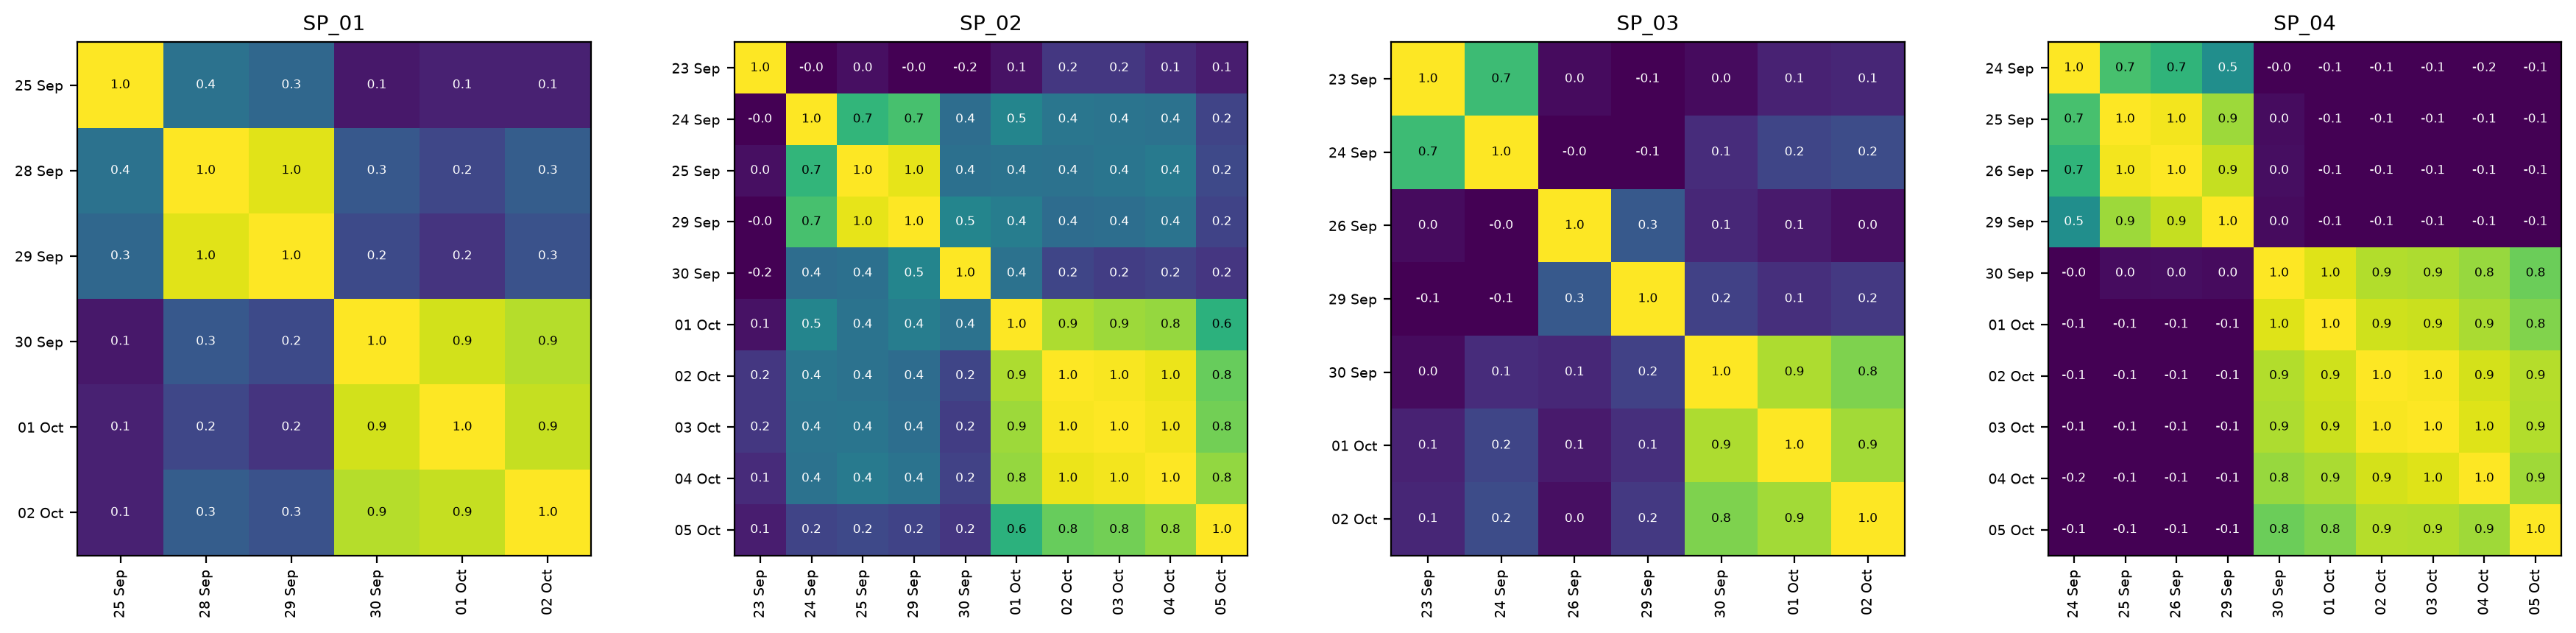

In [ ]:
#| eval: false
plot_scene_similarity(scene_similarity(mdf))

The analysis of a batch records the dates of its scene changes. `periods` turns them into filters for time-indexed tables, one per stretch with the same scene. Each period starts at a change date and ends before the next one:

In [ ]:
#| export
def periods(
    bounds=(), # Dates of scene changes
)->dict: # Filter per period, for tables indexed by time
    "Split a time-indexed table at each date in `bounds`"
    b = [None] + list(pd.to_datetime(list(bounds))) + [None]
    def flt(s, e):
        def f(w):
            m = np.ones(len(w), bool)
            if s is not None: m &= w.index >= s
            if e is not None: m &= w.index < e
            return w[m]
        return f
    def name(s, e):
        if s is None and e is None: return 'all'
        if s is None: return f'before {e:%d %b}'
        if e is None: return f'from {s:%d %b}'
        return f'{s:%d %b} to {e:%d %b}'
    return {name(s, e): flt(s, e) for s, e in zip(b, b[1:])}

In [ ]:
w = pd.DataFrame({'a': range(9)}, index=pd.date_range('2026-09-28', periods=9, freq='12h'))
ps = periods(['2026-09-30'])
test_eq(list(ps), ['before 30 Sep', 'from 30 Sep'])
test_eq([len(f(w)) for f in ps.values()], [4, 5])
test_eq(list(periods()), ['all'])

## Comparing nodes

`node_table` puts one column of `leaf_series` output side by side for all nodes. All nodes measure on the same 5-minute grid to within a second. Rounding times to 5 minutes therefore aligns them:

In [ ]:
#| export
def node_table(
    df:pd.DataFrame, # Output of `leaf_series`
    col:str, # Column to tabulate
)->pd.DataFrame: # One column per node, indexed by time rounded to 5 minutes
    "One column per node on a shared 5-minute time index"
    df = df.assign(t=df.time.dt.round('5min')).drop_duplicates(['node_id', 't'])
    return df.pivot(index='t', columns='node_id', values=col)

Over all hours, nights and days form two clusters, and a line fitted through two clusters mostly measures the gap between them. Comparisons are therefore made within each regime. `regimes` splits a time-indexed table into day, from sunrise to sunset, and night. `combine` crosses regimes with the periods of a batch:

In [ ]:
#| export
regimes = dict(night=lambda w: w[~is_day(w.index)], day=lambda w: w[is_day(w.index)])

def combine(
    periods:dict, # Output of `periods`
    regimes:dict=regimes, # Filter per regime
)->dict: # Filter per regime and period
    "Filters for each regime within each period"
    return {f'{r}, {p}': (lambda w, fr=fr, fp=fp: fr(fp(w))) for p, fp in periods.items() for r, fr in regimes.items()}

A correlation says whether two series move together, not whether they agree. `pair_stats` gives, for each pair of columns and each group of times, the bias (the mean of `y` minus `x`), the line fitted to `y` against `x`, and the correlation. A slope of 1 means both see the same swing. Groups with fewer than 3 shared values are skipped:

In [ ]:
#| export
def pair_stats(
    w:pd.DataFrame, # Output of `node_table`, optionally with an `air` column
    groups:dict, # Filter per group of times, such as the output of `combine`
)->pd.DataFrame: # One row per pair and group
    "Bias, fitted line and correlation of `y` against `x`, for each pair of columns of `w` and each group"
    rows = []
    for (x, y), (p, f) in itertools.product(itertools.combinations(w.columns, 2), groups.items()):
        d = f(w)[[x, y]].dropna()
        if len(d) < 3: continue
        k, c0 = np.polyfit(d[x], d[y], 1)
        rows.append(dict(x=x, y=y, group=p, n=len(d), bias=(d[y] - d[x]).mean(), slope=k, intercept=c0, r=d[x].corr(d[y])))
    return pd.DataFrame(rows).round(2)

In [ ]:
t = pd.date_range('2026-10-01', periods=48, freq='h')
w = pd.DataFrame({'a': np.arange(48.)}, index=t).assign(b=lambda d: 2 * d.a + 1)
st = pair_stats(w, {'all': lambda w: w})
test_eq(st[['bias', 'slope', 'intercept', 'r']].iloc[0].tolist(), [24.5, 2.0, 1.0, 1.0])

`scatter_matrix` plots each pair of columns against each other, one colour and one fitted line per group. The dashed line is 1:1:

In [ ]:
#| export
def scatter_matrix(
    w:pd.DataFrame, # Output of `node_table`, optionally with an `air` column
    groups:dict=regimes, # Filter per group of times
    label:str='°C', # Unit of the axes
    title:str='', # Figure title
):
    "Pairwise scatter plots of the columns of `w`, with one fitted line per group"
    names = list(w.columns)
    fig, axs = plt.subplots(len(names), len(names), figsize=(2.6 * len(names), 2.6 * len(names)))
    lo, hi = np.nanmin(w.to_numpy()), np.nanmax(w.to_numpy())
    for i, j in itertools.product(range(len(names)), repeat=2):
        ax = axs[i, j]
        if j >= i:
            ax.axis('off')
            if i == j: ax.text(0.5, 0.5, names[i], ha='center', va='center', fontsize=12)
            continue
        for k, (p, f) in enumerate(groups.items()):
            d = f(w)[[names[j], names[i]]].dropna()
            if len(d) < 3: continue
            ax.scatter(d.iloc[:, 0], d.iloc[:, 1], s=2, alpha=0.3, c=f'C{k}', label=p)
            kk, c0 = np.polyfit(d.iloc[:, 0], d.iloc[:, 1], 1)
            ax.plot([lo, hi], [kk * lo + c0, kk * hi + c0], c=f'C{k}', lw=1.5)
        ax.plot([lo, hi], [lo, hi], c='k', ls='--', lw=0.8)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.tick_params(labelsize=7)
        if j == 0: ax.set_ylabel(f'{names[i]} ({label})', fontsize=8)
        if i == len(names) - 1: ax.set_xlabel(f'{names[j]} ({label})', fontsize=8)
    axs[1, 0].legend(fontsize=7, markerscale=4)
    fig.suptitle(title)
    plt.tight_layout()

For example, the unmasked leaf temperature of each node in batch 1 against air temperature and the other nodes, from the scene change on 30 September:

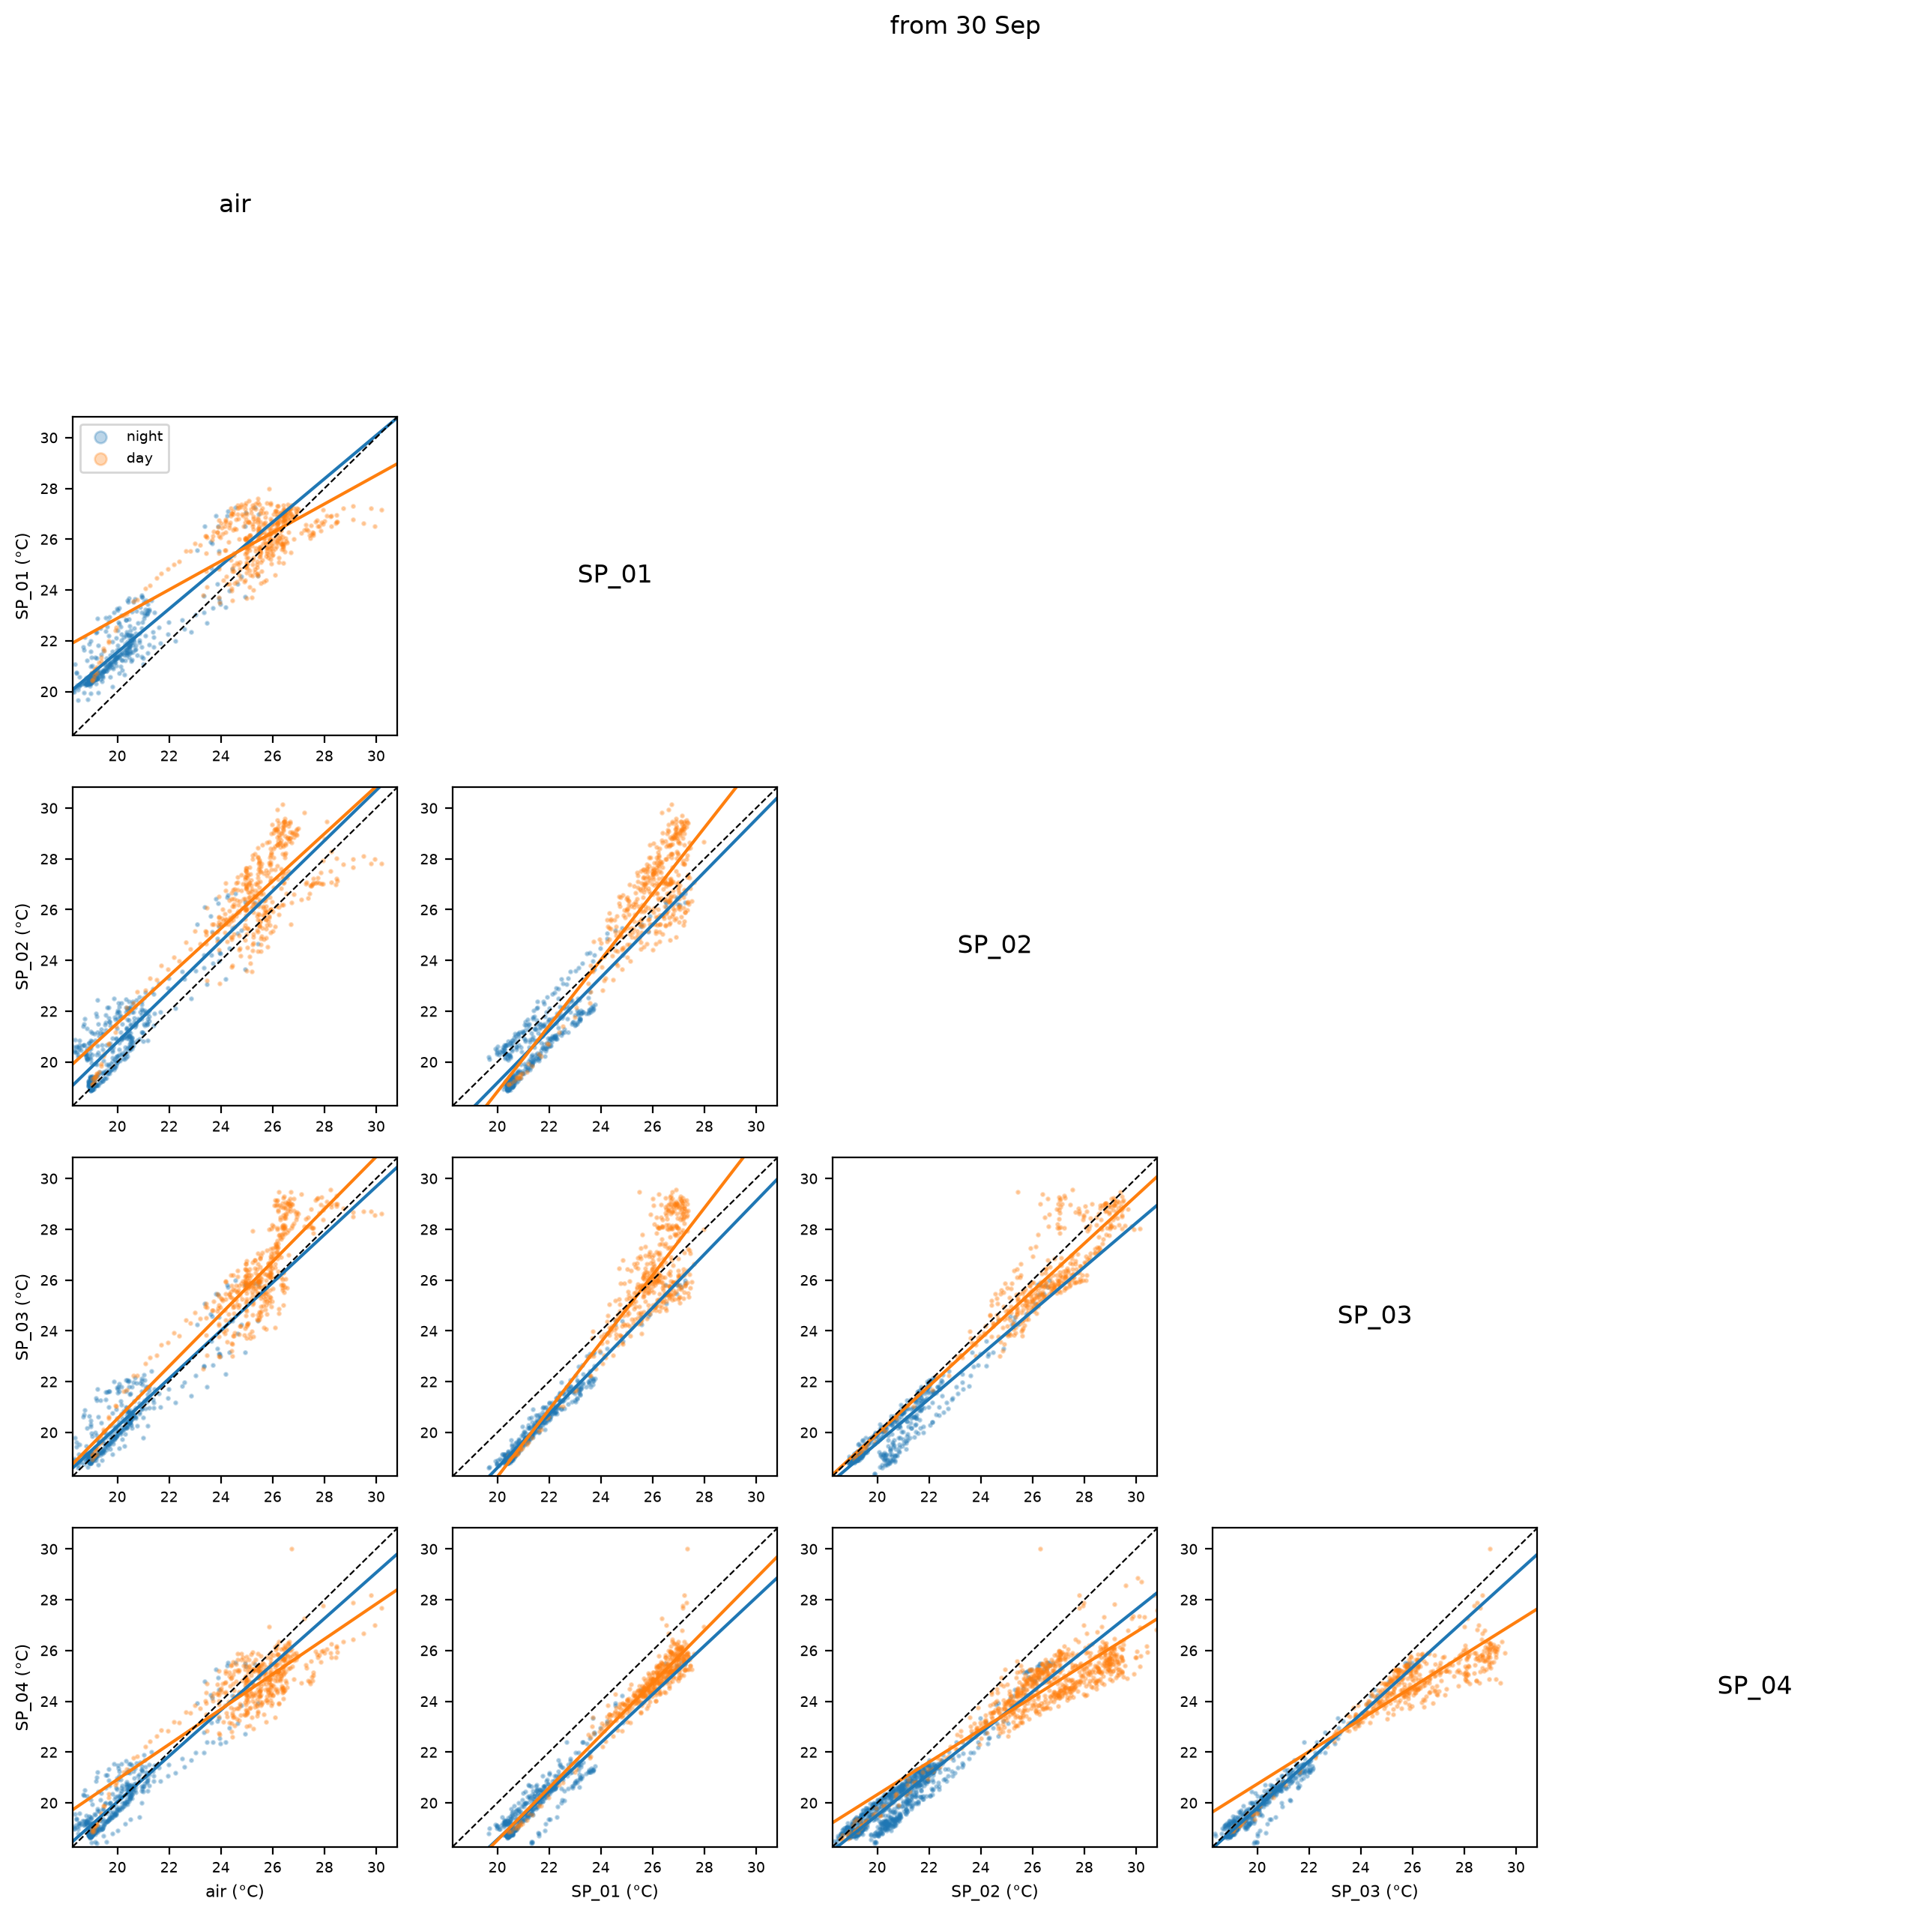

,x,y,group,n,bias,slope,intercept,r
0,air,SP_01,"night, before 30 Sep",322,2.20,0.93,3.62,0.94
1,air,SP_01,"day, before 30 Sep",400,0.92,0.70,8.73,0.77
2,air,SP_01,"night, from 30 Sep",393,1.54,0.85,4.47,0.87
3,air,SP_01,"day, from 30 Sep",438,0.57,0.56,11.63,0.76
4,air,SP_02,"night, before 30 Sep",280,0.57,0.97,1.15,0.91
5,air,SP_02,"day, before 30 Sep",318,0.20,0.84,4.28,0.89
6,air,SP_02,"night, from 30 Sep",394,0.79,0.99,0.98,0.87
7,air,SP_02,"day, from 30 Sep",413,1.17,0.93,2.88,0.82
8,air,SP_03,"night, before 30 Sep",271,0.47,0.92,2.17,0.89
9,air,SP_03,"day, before 30 Sep",311,0.90,0.97,1.64,0.79


In [ ]:
#| eval: false
us = leaf_series(mdf, no_masks(full_days(mdf, min_n=13)))
tl = node_table(us, 't_leaf')
tl.insert(0, 'air', node_table(us, 't_air').mean(axis=1))
after = periods(['2026-09-30'])['from 30 Sep']
scatter_matrix(after(tl), title='from 30 Sep')
pair_stats(tl, combine(periods(['2026-09-30']))).query("x == 'air'")

## Daily fits

A fit over several days averages away a change in how a plant follows its surroundings, and water stress is such a change. A leaf that transpires well warms more slowly than the air during the day. Its daytime slope against air is below 1. When its stomata close, the slope moves towards 1 and the intercept rises. At night the stomata are mostly closed. Night fits are then a reference for the same plant.

`peers` gives, for each node, the mean of the other nodes. It is a reference that needs no air sensor and that cancels the shared greenhouse climate, as long as most plants are not stressed.

In [ ]:
#| export
def peers(
    w:pd.DataFrame, # Output of `node_table`
)->pd.DataFrame: # Same shape as `w`
    "Mean of the other columns, for each column"
    return w.apply(lambda c: w.drop(columns=c.name).mean(axis=1))

`daily_fits` fits a line through each node against a reference, for each day and regime. The reference is one series shared by all nodes, such as air temperature, or a table with one column per node, such as the output of `peers`. A night takes the date of the evening it starts: the night of 5 October runs from sunset on 5 October to sunrise on 6 October. The bias is the mean of the node minus the reference, as in `pair_stats`. The intercept is the fitted value at a reference of 0, far outside the data, and it moves with the slope. The fit is ordinary least squares. Noise in the reference pulls the slope towards 0, more against `peers` than against air. This effect is about the same every day, and changes over days remain comparable.

In [ ]:
#| export
def daily_fits(
    w:pd.DataFrame, # Output of `node_table`
    x, # Reference: a series shared by all nodes, or a table with the columns of `w`
    min_n:int=24, # Fewest points for a fit
)->pd.DataFrame: # One row per node, day and regime
    "Bias, slope, intercept and correlation of each node against `x`, per day and regime"
    day = is_day(w.index)
    key = np.where(day, w.index.normalize(), (w.index - pd.Timedelta('12h')).normalize())
    rows = []
    for node in w.columns:
        ref = x[node] if isinstance(x, pd.DataFrame) else x
        d = pd.DataFrame(dict(x=ref, y=w[node], date=key, regime=np.where(day, 'day', 'night')), index=w.index).dropna()
        for (date, regime), g in d.groupby(['date', 'regime']):
            if len(g) < min_n: continue
            k, c0 = np.polyfit(g.x, g.y, 1)
            rows.append(dict(node_id=node, day=date, regime=regime, n=len(g), bias=(g.y - g.x).mean(), slope=k, intercept=c0, r=g.x.corr(g.y)))
    return pd.DataFrame(rows)

A synthetic node that follows the air with a slope of 0.5 by day and 1 by night:


In [ ]:
t = pd.date_range('2026-10-01', '2026-10-03', freq='5min', inclusive='left')
air = pd.Series(15 + 5 * np.sin(2 * np.pi * (t.hour + t.minute / 60 - 9) / 24), index=t)
w = pd.DataFrame(dict(a=np.where(is_day(t), 0.5 * air + 8, air)), index=t)
fits = daily_fits(w, air)
test_close(fits.slope.to_numpy(), np.where(fits.regime == 'day', 0.5, 1.))
fits.round(dict(bias=2, slope=2, intercept=2, r=2))

,node_id,day,regime,n,bias,slope,intercept,r
0,a,2026-09-30,night,83,0.00,1.0,0.0,1.0
1,a,2026-10-01,day,140,-0.85,0.5,8.0,1.0
2,a,2026-10-01,night,148,0.00,1.0,0.0,1.0
3,a,2026-10-02,day,140,-0.85,0.5,8.0,1.0
4,a,2026-10-02,night,65,0.00,1.0,-0.0,1.0
